In [126]:
#TASK1
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [127]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, train_size=10000, test_size=2000, random_state=42, stratify=y
)

In [129]:
X_train[0].shape #this is a vector of one photo 784 rows - normalised

(784,)

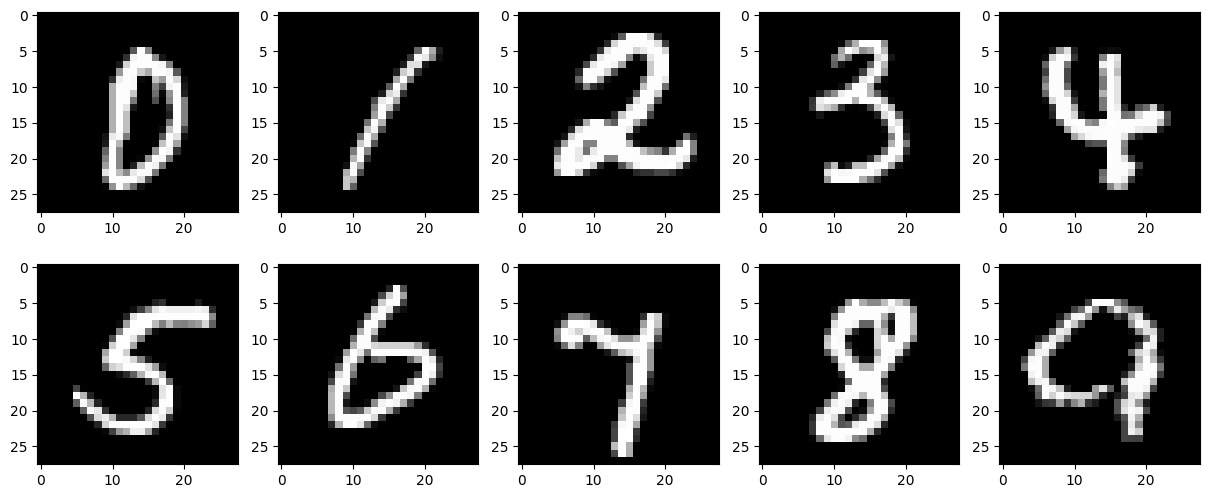

In [130]:
#1.1
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 6))

for i in range(1, 11):
    ax = fig.add_subplot(2, 5, i)

    if i == 1:
        plt.imshow(X_train[1048].reshape(28, 28), cmap="gray")
        
    elif i == 2:
        plt.imshow(X_train[1003].reshape(28, 28), cmap="gray")
        
    elif i == 3:
        plt.imshow(X_train[1005].reshape(28, 28), cmap="gray")
        
    elif i == 4:
        plt.imshow(X_train[1022].reshape(28, 28), cmap="gray")
        
    elif i == 5:
        plt.imshow(X_train[1040].reshape(28, 28), cmap="gray")

    elif i == 6:
        plt.imshow(X_train[1024].reshape(28, 28), cmap="gray")
        
    elif i == 7:
        plt.imshow(X_train[1026].reshape(28, 28), cmap="gray")

    elif i == 8:
        plt.imshow(X_train[1035].reshape(28, 28), cmap="gray")
        
    elif i == 9:
        plt.imshow(X_train[1046].reshape(28, 28), cmap="gray")

    elif i == 10:
        plt.imshow(X_train[1055].reshape(28, 28), cmap="gray")


In [131]:
#1.2
#By default the lbfgs model is used the default iterations is 100
import time

start_time = time.time()

from sklearn.linear_model import LogisticRegression

logireg = LogisticRegression(solver='lbfgs',max_iter=100,n_jobs=-1)
logireg.fit(X_train,y_train)

end_time = time.time()
total_time = end_time - start_time

print(total_time)

/usr/local/lib64/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


4.179494142532349


In [132]:
#No the model does not converge in the default convergernce iterations we need to change the 
#iteration limit

import time

start_time = time.time()

logireg = LogisticRegression(solver='lbfgs',max_iter=165,n_jobs=-1)
logireg.fit(X_train,y_train)

end_time = time.time()
total_time = end_time - start_time

print(total_time)

5.884402751922607


In [133]:
from sklearn.metrics import accuracy_score

y_pred = logireg.predict(X_test)
print(accuracy_score(y_pred,y_test))

0.9085


In [134]:
logireg = LogisticRegression(solver='lbfgs',max_iter=165,n_jobs=-1)
model_28 = logireg.fit(X_train,y_train)

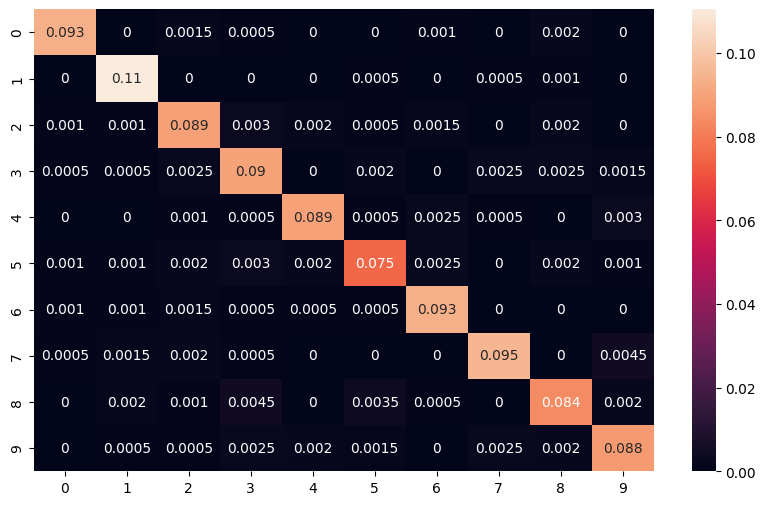

In [135]:
#1.3
from sklearn.metrics import confusion_matrix
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred, normalize='all'),annot=True)
plt.show()

In [136]:
#ok from this map we can say that (7,9) and (8,3) have the highest confusion 

In [137]:
pip install scikit-image


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [138]:
import skimage as ski
from skimage.transform import resize
import numpy as np

In [139]:
X_train_14 = np.array([resize(img.reshape(28, 28), (14, 14), anti_aliasing=True).ravel() for
img in X_train])

In [140]:
X_train_14[:100].shape # from this we can see that our dataset have been downsized to 14x14

(100, 196)

In [141]:
X_test_14 = np.array([resize(img.reshape(28, 28), (14, 14), anti_aliasing=True).ravel() for
img in X_test])

In [142]:
X_test_14[:100].shape 

(100, 196)

In [143]:
X_train_7 = np.array([resize(img.reshape(28, 28), (7, 7), anti_aliasing=True).ravel() for
img in X_train])

In [144]:
X_test_7 = np.array([resize(img.reshape(28, 28), (7, 7), anti_aliasing=True).ravel() for
img in X_test])

In [145]:
X_train_7[:100].shape

(100, 49)

In [146]:
X_test_7[:100].shape

(100, 49)

In [147]:
#2.2 Ok now we have the resolutions now we can train the models 

In [148]:
#Testing for resolution A
logireg = LogisticRegression(solver='lbfgs',max_iter=165,n_jobs=-1)
model14 = logireg.fit(X_train_14,y_train)
y_pred_14 = logireg.predict(X_test_14)

print(accuracy_score(y_pred_14,y_test))

0.9125


In [149]:
#Testing for resolution B
logireg = LogisticRegression(solver='lbfgs',max_iter=165,n_jobs=-1)
logireg.fit(X_train_7,y_train)
model7 = y_pred_7 = logireg.predict(X_test_7)

print(accuracy_score(y_pred_7,y_test))

0.88


In [181]:
#2.3 
#The model lost around 2% of accuracy 


In [187]:
#TASK 3
#3.1
learned_coef_matrix = model_28.coef_
learned_coef_matrix.shape

(10, 784)

In [188]:
import skimage as ski
from skimage.transform import resize
import numpy as np

In [193]:
reshaped_coef = np.array([img.reshape(28,28) for img in learned_coef_matrix])
reshaped_coef.shape

(10, 28, 28)

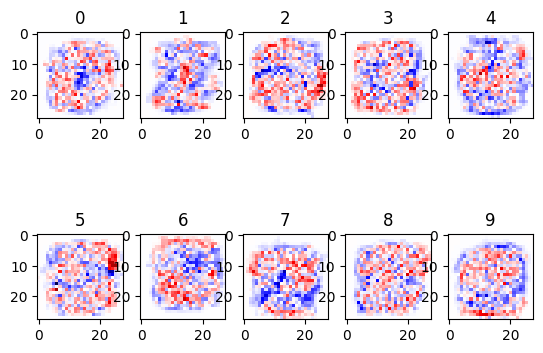

In [215]:
fig,ax = plt.subplots(2,5)
for index in range(10):
    scale = np.max(np.abs(learned_coef_matrix))
    ax[index//5,index%5].imshow(reshaped_coef[index],cmap="seismic",vmin=-scale,vmax=scale)
    ax[index//5,index%5].set_title(index)

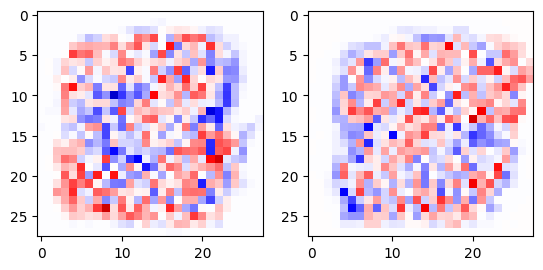

In [224]:
fig,ax = plt.subplots(1,2)
ax[0].imshow(reshaped_coef[3],cmap="seismic",vmin=-scale,vmax=scale)
ax[1].imshow(reshaped_coef[8],cmap="seismic",vmin=-scale,vmax=scale)


In [ ]:
#ok what happens is multiple classes occupt the same pixel coordinates 
# means when two different digits share the exact pixel example is 1 and 7 

In [180]:
#Q4
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(3)
knn.fit(X_train_14,y_train)

KNeighborsClassifier(n_neighbors=3)

In [169]:
#Compare time on both Logisitc regression and KNN

#KNN Regrssion 
from sklearn.neighbors import KNeighborsClassifier
start = time.time()
knn = KNeighborsClassifier(3)
knn.fit(X_train_14,y_train)
end = time.time()

y_pred_knn = knn.predict(X_test_14)
print(f"Total training time : {end-start}")
print(f"Accuracy Score : {accuracy_score(y_pred_knn,y_test)}")

Total training time : 0.011378288269042969
Accuracy Score : 0.957


In [175]:
#4.2
from sklearn.linear_model import LogisticRegression
start = time.time()
logr = LogisticRegression(max_iter=165)
logr.fit(X_train_14,y_train)
end = time.time()

y_pred_logr = logr.predict(X_test_14)
print(f"Total training time : {end-start}")
print(f"Accuracy Score : {accuracy_score(y_pred_logr,y_test)}")

Total training time : 1.0077545642852783
Accuracy Score : 0.9125


In [225]:
#Training sample data is N 
#feature count is d 

#ok for KNN it is doing computation for each point distance -> O(d^n) then sorting on the basis of distances
#for logistic regression O(N*d)
